In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('crop_yield_dataset_extended_full.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42900 entries, 0 to 42899
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          42900 non-null  object 
 1   Crop_Type     42900 non-null  object 
 2   Soil_Type     42900 non-null  object 
 3   Soil_pH       42900 non-null  float64
 4   Temperature   42900 non-null  float64
 5   Humidity      42900 non-null  float64
 6   Wind_Speed    42900 non-null  float64
 7   N             42900 non-null  float64
 8   P             42900 non-null  float64
 9   K             42900 non-null  float64
 10  Crop_Yield    42900 non-null  float64
 11  Soil_Quality  42900 non-null  float64
dtypes: float64(9), object(3)
memory usage: 3.9+ MB


In [4]:
df.tail()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
42895,2025-09-29,Cotton,Sandy,6.75,23.740802,76.259198,6.927179,55.0,44.0,36.0,41.490909,39.375000
42896,2025-09-29,Sugarcane,Clay,6.25,17.365448,80.000000,6.043353,78.0,60.0,48.0,19.242284,54.250000
42897,2025-09-29,Tomato,Loamy,6.50,21.429482,78.570518,8.345060,70.0,54.0,50.0,54.858617,58.000000
42898,2025-09-29,Potato,Saline,8.00,24.884006,75.115994,11.283505,71.5,55.0,40.5,32.140378,13.916667
42899,2025-09-29,Sunflower,Saline,8.00,18.787107,80.000000,13.200299,65.0,60.5,49.5,60.732022,14.583333


In [5]:
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)


In [6]:
df=df.select_dtypes(include=['number'])

In [ ]:
df=df.resample('D').mean()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,,
2014-01-01,6.275,15.994309,79.994742,8.163837,64.55,51.60,40.50,37.073799,35.920833
2014-01-02,6.575,15.639907,79.998234,9.669001,67.00,54.05,43.15,34.636737,32.750000
2014-01-03,6.450,15.156596,79.028168,11.052915,66.50,53.30,42.35,22.107670,41.579167
2014-01-04,6.950,15.026332,79.479529,10.162655,68.70,55.80,44.75,28.197627,40.587500
2014-01-05,6.400,13.828252,80.000000,10.523809,68.45,55.65,45.00,26.062550,51.362500
...,...,...,...,...,...,...,...,...,...
2025-09-25,6.725,20.881731,77.810330,9.093476,67.80,54.75,43.50,48.814043,34.804167
2025-09-26,6.225,21.998287,76.714310,9.351414,63.50,50.80,39.95,28.748145,41.979167
2025-09-27,6.625,20.293528,77.965430,10.838171,63.35,50.65,39.80,40.287717,34.970833


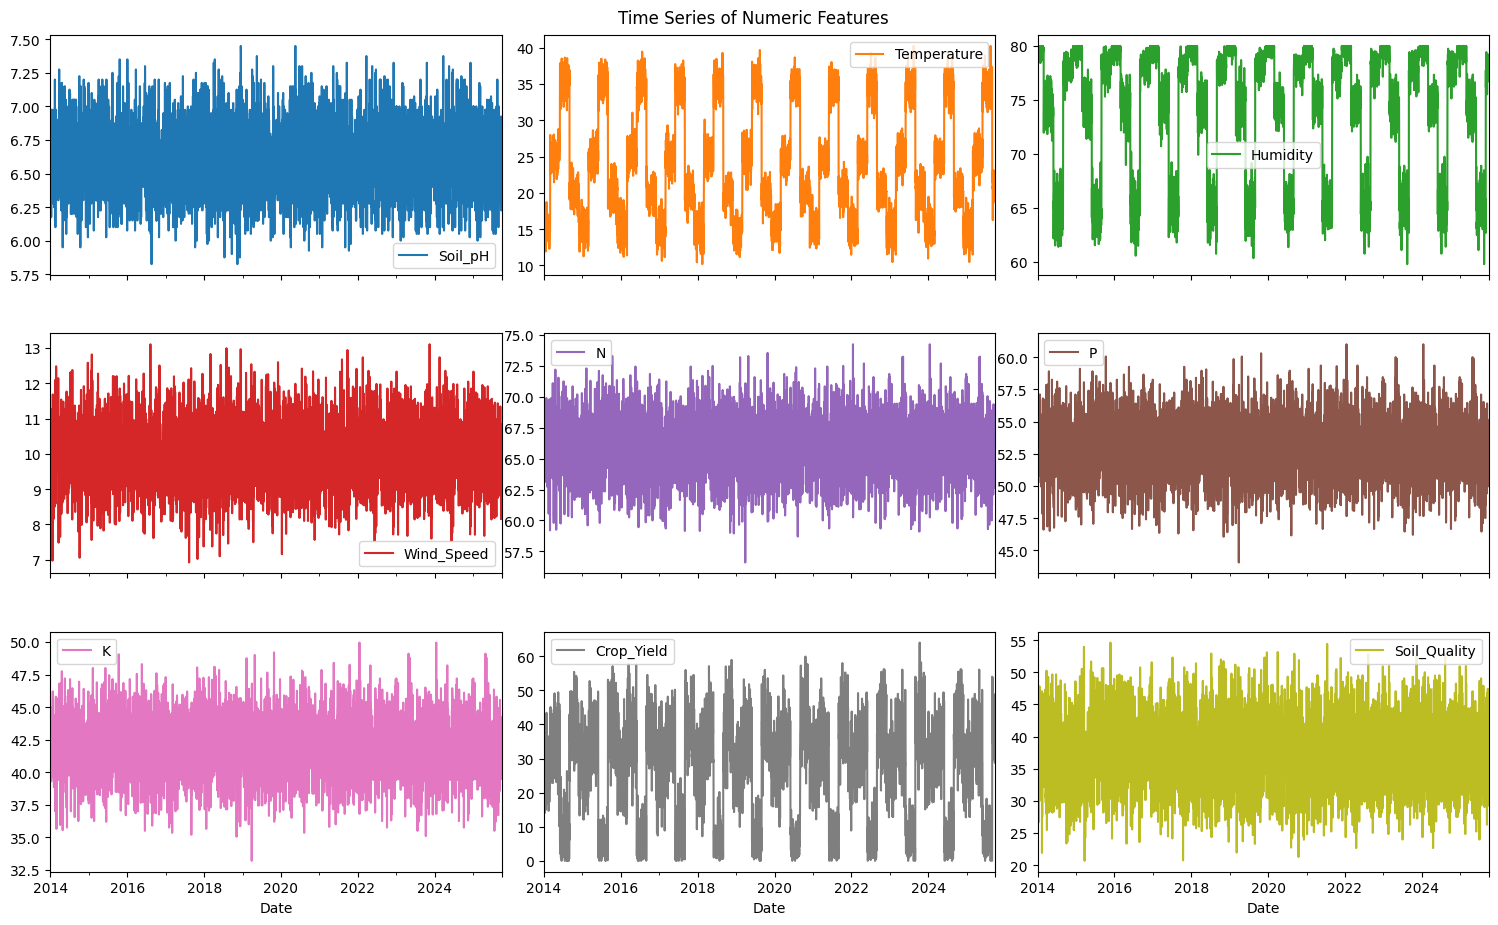

In [8]:
num_cols = ['Soil_pH','Temperature','Humidity','Wind_Speed',
            'N','P','K','Crop_Yield','Soil_Quality']


df[num_cols].plot(subplots=True, layout=(4,3), figsize=(15,12), title="Time Series of Numeric Features")
plt.tight_layout()
plt.show()


### AutoCorrelation

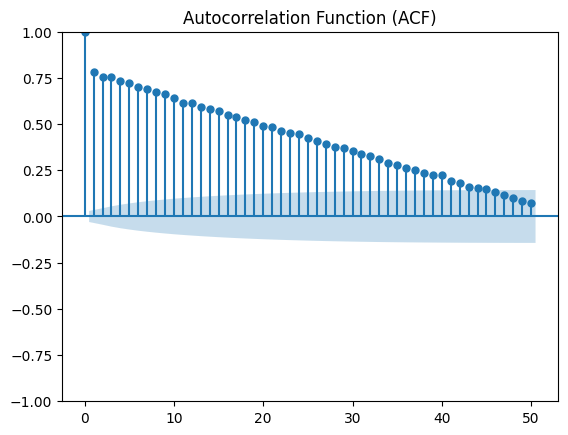

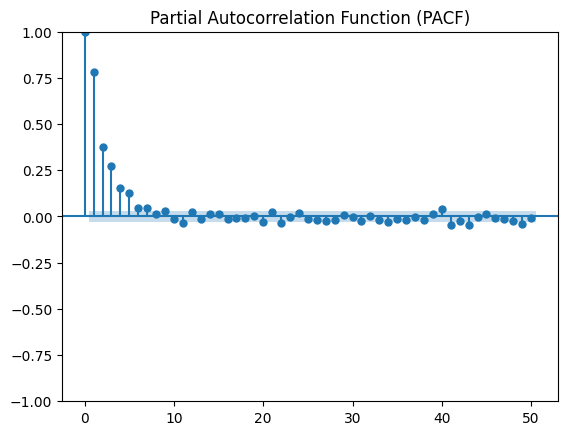

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


y= df['Crop_Yield']

# Plot ACF and PACF
plot_acf(y, lags=50)
plt.title('Autocorrelation Function (ACF)')
plt.show()

plot_pacf(y, lags=50)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

### Testing

In [10]:
from statsmodels.tsa.stattools import adfuller
# Perform ADF test
adf_test = adfuller(y)

print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f'\t{key}: {value}')

ADF Statistic: -6.82859939869022
p-value: 1.9192953093748973e-09
Critical Values:
	1%: -3.4318795063432592
	5%: -2.8622158513096414
	10%: -2.567129760779626


In [11]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS test
kpss_test = kpss(y, regression='c') 

print(f'KPSS Statistic: {kpss_test[0]}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'\t{key}: {value}')

KPSS Statistic: 0.013721303593154356
p-value: 0.1
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


C:\Users\USER\AppData\Local\Temp\ipykernel_5916\591996375.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(y, regression='c')


### Model_Building

In [12]:
exog_vars=['Soil_pH','Temperature','Humidity','Wind_Speed',
            'N','P','K','Soil_Quality']
exog=df[exog_vars]

In [13]:
from statsmodels.tsa.arima.model import ARIMA
model_multi=ARIMA(df['Crop_Yield'],exog,order=(1,0,1)).fit()

In [14]:
# forecast_multi=model_multi.forecast(steps=len(df),exog=exog)
# forecast_multi

In [15]:

forecast_steps = 7
forecast_multi = model_multi.forecast(steps=forecast_steps, exog=exog.tail(forecast_steps))
print(f"Generated forecast for {forecast_steps} steps.")
forecast_multi

Generated forecast for 7 steps.


2025-09-30    46.764915
2025-10-01    40.638407
2025-10-02    41.716244
2025-10-03    38.716746
2025-10-04    38.851464
2025-10-05    39.652168
2025-10-06    35.198269
Freq: D, Name: predicted_mean, dtype: float64

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Assuming forecast_multi is 7-day forecast starting from last available date
actual = df['Crop_Yield'][-7:]  # last 7 days
rmse = mean_squared_error(actual, forecast_multi)
mae = mean_absolute_error(actual, forecast_multi)
print(f'RMSE: {rmse}, MAE: {mae}')


RMSE: 25.53892524915051, MAE: 3.8721494189933736


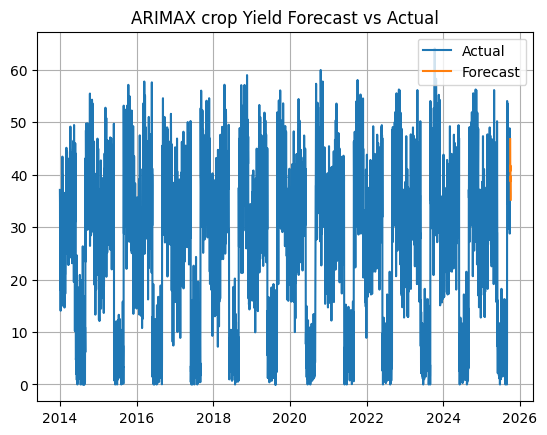

In [17]:
# plt.figure(figsize=(12, 6))
plt.plot(df.index,df['Crop_Yield'],label='Actual')
plt.plot(forecast_multi.index,forecast_multi,label='Forecast')
plt.legend()
plt.grid()
plt.title('ARIMAX crop Yield Forecast vs Actual')
plt.show()

In [18]:
import joblib

# Example: save trained model
joblib.dump(model_multi, "multivariate_model.pkl")


['multivariate_model.pkl']